In [38]:
import sys

print(sys.executable)

C:\Users\lokes\miniconda3\envs\learning_ai\python.exe


In [39]:
#Important Lib
import pandas as pd

In [40]:
#Data Loading
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame = True)
X = housing['data']
y = housing['target']
# features -> X
# target -> y

#Merging them so i can work wiht missing values when doing Data Cleaning
df = pd.concat([X,y],axis=1)
print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedHouseVal  
0      

In [41]:
# Data Cleaning

# Missing vlaues 
df.isnull().sum() # no null values 
df.shape
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [42]:
#insights
df.corr()["MedHouseVal"].sort_values(ascending = False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [43]:
#From the .corr() we can see that MedInc impact the price(Medhouseval) of the house
#Which said that the Rich people areas chnages the house price

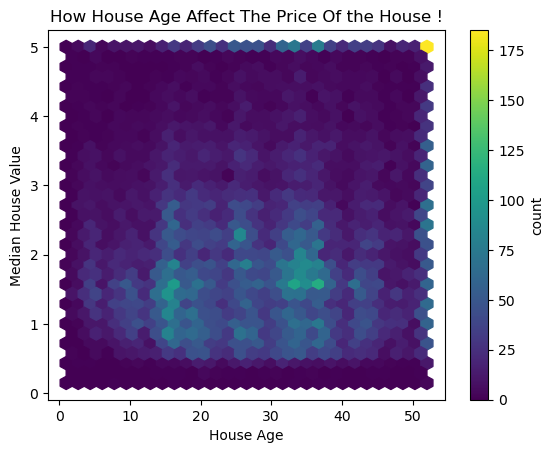

In [44]:
# Visualization
import matplotlib.pyplot as plt
# How houseage affects it's Price
plt.hexbin(df['HouseAge'],df['MedHouseVal'],gridsize=30,cmap='viridis')
plt.colorbar(label="count")
plt.xlabel("House Age")
plt.ylabel("Median House Value")
plt.title("How House Age Affect The Price Of the House !")
plt.show()

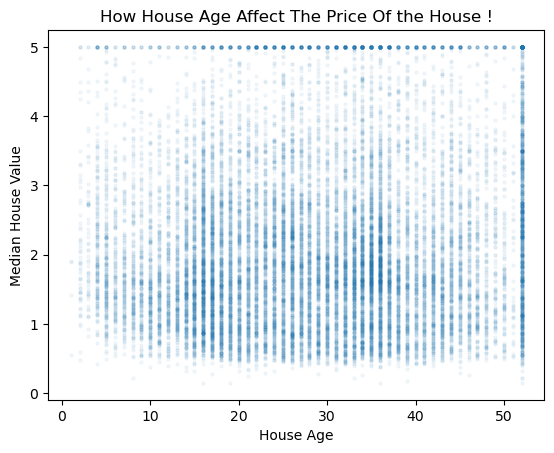

In [45]:
plt.scatter(df['HouseAge'],df['MedHouseVal'],alpha=0.05,s=5)
plt.xlabel("House Age")
plt.ylabel("Median House Value")
plt.title("How House Age Affect The Price Of the House !")
plt.show()

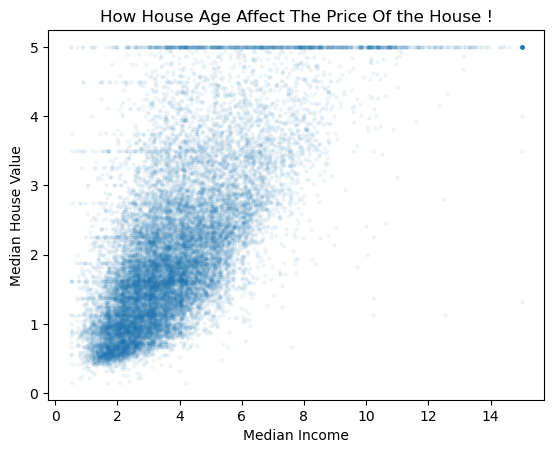

In [46]:
plt.scatter(df['MedInc'],df['MedHouseVal'],alpha=0.05,s=5)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("How House Age Affect The Price Of the House !")
plt.show()

In [47]:
# Feature Engineering 
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [74]:
# Question is rich people among the low populations ?
df['MedHouseVal'].max()#5
df['MedHouseVal'].min()#0.1
df['Population'].max()#35682
df['Population'].min()#3.0
df['Population'].mean()#1425
df['High/Low'] = 0
df['High/Low'] =(df['MedHouseVal'] > 4).astype(int)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,High/Low,RoomsPerHousehold,BedroomRatio
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1,2.732919,0.146591
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0,2.956685,0.155797
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0,2.957661,0.129516
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0,2.283154,0.184458
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0,2.879646,0.172096


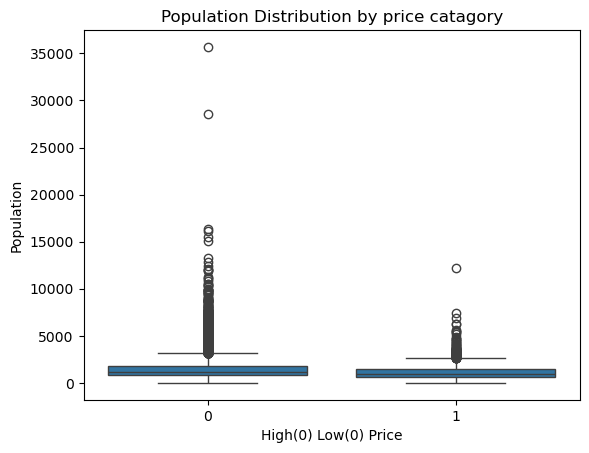

In [66]:
import seaborn as sns

sns.boxplot(x='High/Low',y='Population',data=df)
plt.xlabel('High(0) Low(0) Price')
plt.ylabel('Population')
plt.title('Population Distribution by price catagory')
plt.show()

In [67]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,High/Low
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0


In [68]:
df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']
df['BedroomRatio'] = df['AveBedrms'] / df['AveRooms']

In [69]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,High/Low,RoomsPerHousehold,BedroomRatio
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1,2.732919,0.146591
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0,2.956685,0.155797
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0,2.957661,0.129516
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0,2.283154,0.184458
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0,2.879646,0.172096


In [80]:
print('Median')
print(df.groupby('High/Low')['Population'].median())
print("Mean")
print(df.groupby('High/Low')['Population'].mean())

High/Low
0    1184.0
1     968.0
Name: Population, dtype: float64
High/Low
0    1448.833404
1    1172.410550
Name: Population, dtype: float64


In [84]:
print('Count')
print(df.groupby('High/Low')['Population'].count())
print('Sum')
print(df.groupby('High/Low')['Population'].sum())

Count
High/Low
0    18896
1     1744
Name: Population, dtype: int64
Sum
High/Low
0    27377156.0
1     2044684.0
Name: Population, dtype: float64


In [85]:
df.corr()['MedHouseVal'].sort_values(ascending=False)


MedHouseVal          1.000000
High/Low             0.705958
MedInc               0.688075
RoomsPerHousehold    0.209482
AveRooms             0.151948
HouseAge             0.105623
AveOccup            -0.023737
Population          -0.024650
Longitude           -0.045967
AveBedrms           -0.046701
Latitude            -0.144160
BedroomRatio        -0.255624
Name: MedHouseVal, dtype: float64

In [86]:
#based on the visualiztion and from the data ,
#1) House Price Differes on Median Income
#2) Low population place tend to have 
#3) Engineered features added real value: RoomsPerHousehold beat the raw column it came from, and BedroomRatio turned out to be a meaningfully strong predictor — stronger than raw room/bedroom counts
#4) House Age Does not affect the House Price
#5) High/Low must be excluded from training the model